# M5: GRU

Ova sveska trenira i ocenjuje M5 GRU nad sekvencama prethodno odigranih mečeva.

Svaka rekurentna arhitektura ima svoju svesku,
nezavisno od druge dve, da bi se moglo raditi paralelno bez sudara u istom
`.ipynb` fajlu. Sve tri dele istu arhitekturu (`models.MatchPredictor`) i istu
petlju treniranja (`train.train_model`) - razlikuje se samo parametar `cell`.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from src.config import MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE, RESULTS_FILE
from src import evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)

## Učitavanje sekvenci

Iste `sekvence.npz` i iste `train`/`validation` pozicije kao u svesci 02/03 - isti mečevi kao za M0/M1, kako bi poredjenje bilo pošteno. Test skup se ovde ne učitava iz istog razloga kao u svesci 03: dodiruje se tačno jednom, na kraju.

In [2]:
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
home_sequences, away_sequences = splits["home_sequences"], splits["away_sequences"]
context, labels = splits["context"], splits["labels"]
train_idx, validation_idx = splits["train"], splits["validation"]

home_train, away_train = home_sequences[train_idx], away_sequences[train_idx]
context_train, y_train = context[train_idx], labels[train_idx]

home_val, away_val = home_sequences[validation_idx], away_sequences[validation_idx]
context_val, y_val = context[validation_idx], labels[validation_idx]

home_train.shape, context_train.shape

((18092, 10, 8), (18092, 24))

## Dataset i DataLoader

`shuffle=True` ovde meša samo redosled kojim mreža vidi već-fiksirane trening mečeve unutar jedne epohe - ne dira podelu na skupove, koja je hronološka i fiksirana još u svesci 02. Validacija se ne meša, jer se na njoj ne trenira.

In [3]:
BATCH_SIZE = 64

dataset_train = sequences.MatchSequenceDataset(home_train, away_train, context_train, y_train)
dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

len(dataset_train), len(dataset_val)

(18092, 2624)

## Model i treniranje

`cell="gru"` daje M5 GRU.

`MatchPredictor` obrađuje sekvencu domaćina i sekvencu gosta **istom** ćelijom (deljene težine), uzima poslednje skriveno stanje svake kao naučeni sažetak forme, nalepi ih uz kontekst i propusti kroz jedan linearni sloj do sirovog logita.

In [4]:
model_gru = models.MatchPredictor(
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="gru",
    hidden_size=64,
    dropout=0.3,
)
model_gru

MatchPredictor(
  (encoder): GRU(8, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=152, out_features=1, bias=True)
)

In [5]:
history = train.train_model(
    model_gru, loader_train, loader_val,
    epochs=100, patience=5, learning_rate=3e-3,
)

best_epoch = int(np.argmin(history["valid_loss"]))
print(f"trenirano {len(history['train_loss'])} epoha (rano zaustavljanje)")
print(
    f"najbolja epoha: {best_epoch + 1}, "
    f"validacija gubitak {history['valid_loss'][best_epoch]:.4f}, "
    f"validacija tacnost {history['valid_accuracy'][best_epoch]:.4f}"
)

trenirano 10 epoha (rano zaustavljanje)
najbolja epoha: 5, validacija gubitak 0.6180, validacija tacnost 0.6551


## Krive učenja

Puna linija je trening, isprekidana validacija. Rastojanje između njih koje raste kroz epohe je znak overfitovanja — mreža pamti trening umesto da uči opšti obrazac.

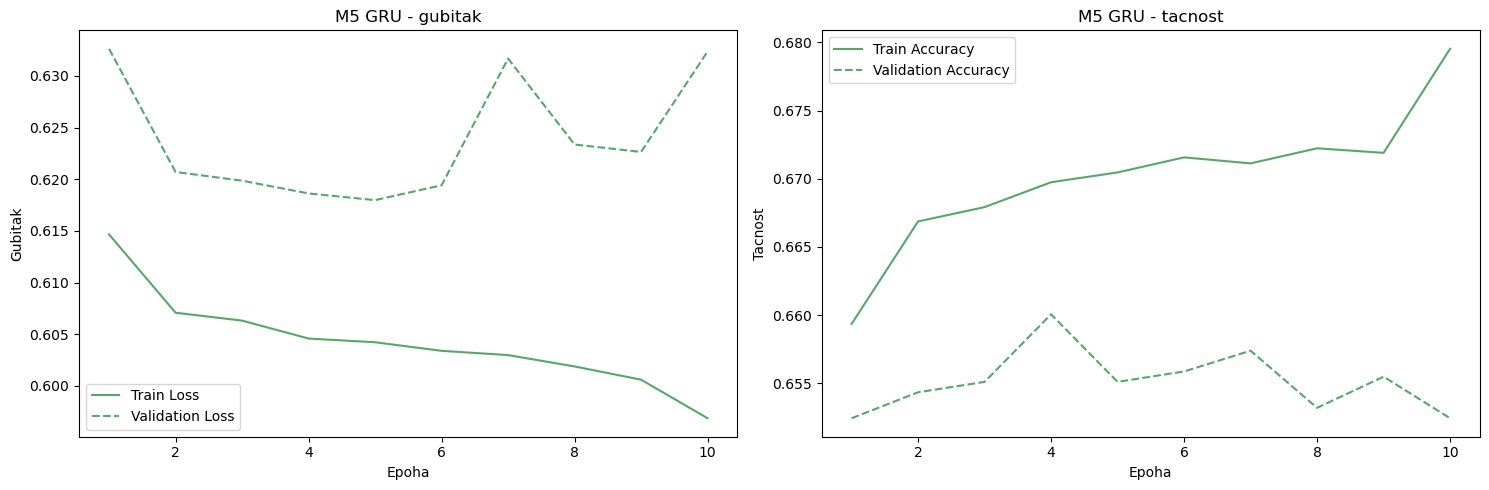

In [6]:
plotting.plot_learning_curves(history, "M5 GRU")

## Evaluacija

Matrica konfuzije i kalibracija na validaciji, metrike u `reports/rezultati.csv` — isti obrazac kao za M0/M1 u svesci 03 i M3 u svesci 04-01. Test skup se ne dodiruje ovde.

In [7]:
for skup, loader in [("trening", loader_train), ("validacija", loader_val)]:
    y_proba, y_true = train.predict_proba(model_gru, loader)
    metrike = evaluate.compute_metrics(y_true, y_proba)
    evaluate.append_results("M5 GRU", skup, metrike)

pd.read_csv(RESULTS_FILE)

,model,skup,tacnost,roc_auc,log_loss,brier
0,M3 RNN,trening,0.676763,0.717653,0.600141,0.206907
1,M3 RNN,validacija,0.655488,0.696478,0.618315,0.214417
2,M0 domacin,trening,0.599547,0.500000,14.433798,0.400453
3,M0 domacin,validacija,0.588796,0.500000,14.821304,0.411204
4,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
5,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363
6,M2 XGBoost,trening,0.683396,0.731799,0.590812,0.202857
7,M2 XGBoost,validacija,0.657012,0.699032,0.616667,0.213756
8,M5 GRU,trening,0.673889,0.715839,0.601378,0.207469
9,M5 GRU,validacija,0.655107,0.698265,0.617979,0.214296


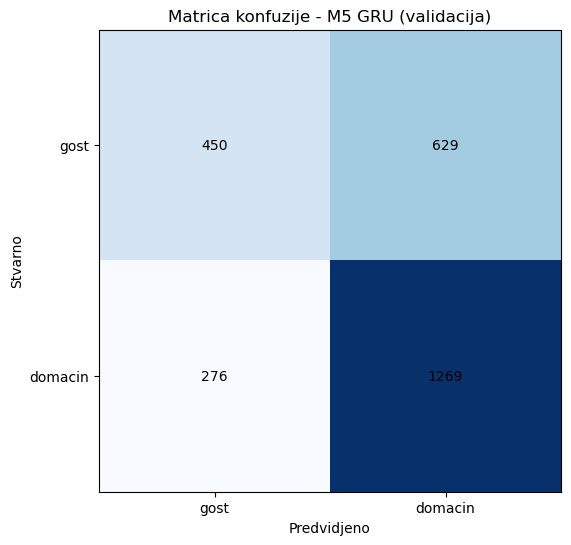

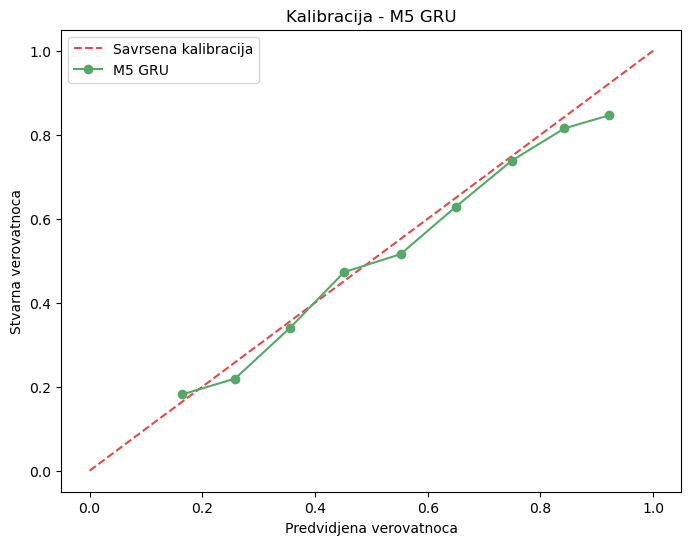

In [8]:
y_proba_val, y_true_val = train.predict_proba(model_gru, loader_val)
y_pred_val = (y_proba_val >= 0.5).astype(int)

evaluate.plot_confusion_matrix(y_true_val, y_pred_val, "Matrica konfuzije - M5 GRU (validacija)")
evaluate.plot_calibration_curve(y_true_val, y_proba_val, "M5 GRU")

Model bolje prepoznaje pobede domaćina (82% recall) nego pobede gosta (42% recall) — ista posledica neravnoteže klasa (~59% pobeda domaćina u treningu) kao kod M3 RNN, ne greška u arhitekturi ili gubitak signala kroz kapije GRU-a.

## Izbor hiperparametara

Pretraga po zajedničkoj mreži vrednosti iz `config.py` (`HIDDEN_SIZE_GRID`, `DROPOUT_GRID`, `LEARNING_RATE_GRID`) - ista mreža vrednosti i ista funkcija (`train.search_hyperparameters`) za sve tri arhitekture (RNN, LSTM, GRU), da poređenje bude pošteno. 27 kombinacija, izbor po ROC-AUC na validaciji, test skup netaknut.

In [9]:
df_search = train.search_hyperparameters(
    loader_train, loader_val, home_train.shape[-1], context_train.shape[-1], cell="gru"
)
df_search.head(10)

,hidden_size,dropout,learning_rate,tacnost,roc_auc,log_loss,brier
0,64,0.30,0.003,0.655107,0.698265,0.617979,0.214296
1,64,0.15,0.003,0.653201,0.697402,0.618552,0.214516
2,32,0.30,0.003,0.656250,0.696866,0.618046,0.214364
3,64,0.00,0.003,0.654726,0.696845,0.618624,0.214612
4,32,0.15,0.003,0.658155,0.696806,0.618036,0.214347
5,128,0.30,0.003,0.653201,0.695586,0.617849,0.214344
6,64,0.00,0.001,0.652439,0.695550,0.619841,0.214982
7,32,0.00,0.003,0.653963,0.695426,0.619237,0.214927
8,128,0.15,0.003,0.656631,0.695176,0.618103,0.214471
9,128,0.00,0.001,0.655869,0.694940,0.619533,0.214973


Najbolja kombinacija se dobija sa jednim semenom, pa se pre prihvatanja potvrđuje treniranjem sa još dva različita semena - jedan trening može biti sreća, tri retko.

In [10]:
best_params = df_search.iloc[0][["hidden_size", "dropout", "learning_rate"]].to_dict()
best_params["hidden_size"] = int(best_params["hidden_size"])

confirmation_seeds = [RANDOM_STATE, RANDOM_STATE + 1, RANDOM_STATE + 2]
confirmation_scores = []
for seed in confirmation_seeds:
    train.set_seed(seed)
    candidate = models.MatchPredictor(
        n_features=home_train.shape[-1], n_context=context_train.shape[-1],
        cell="gru", hidden_size=best_params["hidden_size"], dropout=best_params["dropout"],
    )
    train.train_model(candidate, loader_train, loader_val, learning_rate=best_params["learning_rate"])
    proba, y_true = train.predict_proba(candidate, loader_val)
    confirmation_scores.append(evaluate.compute_metrics(y_true, proba)["roc_auc"])

best_params, confirmation_scores

({'hidden_size': 64, 'dropout': 0.3, 'learning_rate': 0.003},
 [0.6982649042773035, 0.6946093560200474, 0.697431098554037])

Sve tri probe daju ROC-AUC u uskom rasponu 0.695-0.698, dakle pobednik nije sreća jednog semena - `hidden_size=64, dropout=0.30, learning_rate=0.003` se prihvata kao konačan izbor. Ovo je isti `hidden_size`/`dropout` kao polazna podrazumevana vrednost, samo veći learning rate (0.003 umesto 0.001).

## Čuvanje modela

Propozicije traže da se sačuvaju istrenirani modeli **i** propratni skaleri. Čuva se stanje sa najmanjim validacionim gubitkom, ne poslednje stanje.

In [11]:
train.save_model(model_gru, "gru.pt")

## Zaključak

M5 (GRU), sa hiperparametrima izabranim pretragom (`hidden_size=64, dropout=0.30, learning_rate=0.003`), dostiže 65.5% tačnosti na validaciji (ROC-AUC 0.698, log-loss 0.618, Brier 0.214) — praktično identično M3 RNN (65.5%, 0.696, 0.618, 0.214) i M1 logističkoj regresiji iz sveske 03 (65.6%, 0.695, 0.620, 0.215). Kapije GRU-a ne donose merljivu prednost nad običnom RNN na ovom skupu, u skladu sa očekivanjem iz plana: snaga tima se unutar sezone menja sporo, pa pokretni prosek već hvata skoro sav dostupan signal - dodatni kapacitet arhitekture nema šta da iskoristi.

Pretraga hiperparametara (27 kombinacija po zajedničkoj mreži vrednosti iz `config.py`) je pomerila learning rate sa 0.001 na 0.003, uz zanemarljivu promenu tačnosti - pobednik je potvrđen sa tri semena (ROC-AUC 0.695-0.698), nije slučajnost jednog treninga.

Krive učenja pokazuju isti obrazac kao kod RNN, samo brži: mreža se skoro sva nauči u prve 2-3 epohe (najbolja je epoha 5 od 10 ukupno treniranih, brže nego pre pretrage zbog većeg learning rate-a), posle čega rano zaustavljanje presreće šum. Matrica konfuzije pokazuje istu asimetriju kao kod RNN: 82% recall za pobede domaćina naspram 42% za pobede gosta, posledica neravnoteže klasa. Kalibracija prati isti obrazac kao kod RNN.

Model je sačuvan u `models/gru.pt`. Sve tri rekurentne arhitekture (RNN, LSTM, GRU) su sada istrenirane sa pretragom hiperparametara.